# Biorep1 Compound Analysis (Aroma Identification → Matched Intensity Matrix)

**What this notebook does:**  
This notebook performs **compound-level analysis** for **biorep1** TD–GC–MS data. It combines compound identification tables (e.g., NIST outputs) across file types (samples/QC/blanks/environment), applies contamination filtering using blanks/environment/QC, and matches identified compounds to the quantified peak table (drift-corrected and normalised in the data-preparation workflow). The final output is an analysis-ready aroma intensity matrix (Variety × Compound) plus summary tables.

**Main steps **
- Load and combine compound identification files; label FileType (sample/QC/blank/env)
- Filter likely contaminants based on overlap with blanks/environment/QC (RT tolerance)
- Harmonise compound names (canonical mapping / alias handling when provided)
- Match compounds to quantified peaks using RT and  m/z tolerances
- Build aroma outputs: long-format matched table + wide intensity matrix (Variety × Compound)
_ Doing classification by GMM, Kmeans and HCA
- link with sensory data
- Sensory score prediction for non-panel varieties

**Module dependency:**  
This notebook uses reusable helper functions from **`compound_analysis_module.py`** for compound parsing, contamination filtering, RT/mz matching, and aroma-matrix construction.

---
**Author:** Fatemeh Monfared  
**Thesis:** Data-Driven Analysis of Potato Aroma and Flavor Using TD–GC–MS and Machine Learning  
**Affiliation:** Hanze University of Applied Sciences  
**Year:** 2026


In [1]:

import glob, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import importlib
from IPython.display import display
import compound_analysis_module 
importlib.reload(compound_analysis_module)
import os, re, glob, yaml, importlib,sys
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# NIST Compound Identification Integration (Samples vs Blank/Env Baseline)

In [2]:

from compound_analysis_module import combine_compound_data

CONFIG_PATH = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
REP = "biorep1"   # switch to "biorep2" when needed

# Ensure module/config directory is importable
MODULE_DIR = os.path.dirname(CONFIG_PATH)
if MODULE_DIR and MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

# Load config
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config[REP]["data_paths"]

sample_files       = paths.get("sample_files", []) or []
blank_files        = paths.get("blank_files", []) or []
env_files          = paths.get("env_files", []) or []
base_compound_dir  = paths.get("base_compound_dir", "")
output_path        = paths.get("output_path", "")

# Normalize paths

def norm(p):
    return os.path.normpath(p) if isinstance(p, str) else p

sample_files      = [norm(p) for p in sample_files]
blank_files       = [norm(p) for p in blank_files]
env_files         = [norm(p) for p in env_files]
base_compound_dir = norm(base_compound_dir)
output_path       = norm(output_path)

# Auto-detect blanks/env if not explicitly provided
if not blank_files:
    blank_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*blank*.csv"))

if not env_files:
    env_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*env*.csv"))

# Ensure output directory exists
out_dir = os.path.dirname(output_path)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

print(f"Rep selected: {REP}")
print(f"Base compound dir: {base_compound_dir}")
print(f"Samples: {len(sample_files)} | blanks: {len(blank_files)} | env: {len(env_files)}")


# Run compound combination
combined_df = combine_compound_data(
    base_dir=base_compound_dir,
    sample_files=sample_files,
    env_files=env_files,
    blank_files=blank_files,
    output_path=output_path
)

print("Done. Rows:", len(combined_df))
if "FileType" in combined_df.columns:
    print(combined_df["FileType"].value_counts())

display(combined_df.head(10))


Rep selected: biorep1
Base compound dir: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds
Samples: 94 | blanks: 1 | env: 1

Combined file saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\biorep1\combined.csv

FileType counts:
FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64

Preview:
   Component RT                  Compound Name  Match Factor  Best Hit  \
0      1.999217                        Propene     65.242228      True   
1      2.177691        2-Propanone, 1-methoxy-     87.899550      True   
2      2.359333            Propanal, 2-methyl-     78.339167      True   
3      2.465450  l-2-Amino-4-methyl-1-pentanol     68.259874      True   
4      2.504033        Undecane, 2,2-dimethyl-     68.175810      True   

   Formula  Base Peak MZ FileType   FileName  RI  
0     C3H6     40.959613   sample  ADORA.csv NaN  
1   C4H8O2     44.960000   sample  ADORA.csv NaN  
2   

,Component RT,Compound Name,Match Factor,Best Hit,Formula,Base Peak MZ,FileType,FileName,RI
0,1.999217,Propene,65.242228,True,C3H6,40.959613,sample,ADORA.csv,NaN
1,2.177691,"2-Propanone, 1-methoxy-",87.899550,True,C4H8O2,44.960000,sample,ADORA.csv,NaN
2,2.359333,"Propanal, 2-methyl-",78.339167,True,C4H8O,42.964126,sample,ADORA.csv,NaN
3,2.465450,l-2-Amino-4-methyl-1-pentanol,68.259874,True,C6H15NO,42.970000,sample,ADORA.csv,NaN
4,2.504033,"Undecane, 2,2-dimethyl-",68.175810,True,C13H28,56.987282,sample,ADORA.csv,NaN
5,2.623000,"1,3,5-Trifluorobenzene",83.196509,True,C6H3F3,131.918292,sample,ADORA.csv,NaN
6,2.893083,"Butanal, 3-methyl-",95.564375,True,C5H10O,43.956820,sample,ADORA.csv,NaN
7,2.979900,Benzene,75.424866,True,C6H6,77.968884,sample,ADORA.csv,NaN
8,3.201767,"1-Hexanol, 2,2-dimethyl-",71.328684,True,C8H18O,42.960000,sample,ADORA.csv,NaN
9,3.311083,Pentanal,85.989404,True,C5H10O,43.955342,sample,ADORA.csv,NaN


The compound tables were successfully combined for biorep1, producing a single dataset with 18,368 rows saved to biorep1/combined.csv. Most detections come from the 94 sample files (18,334 rows), while the blank (12 rows) and environment (22 rows) files contribute a small background set that can be used for contamination filtering and identifying non-sample signals.

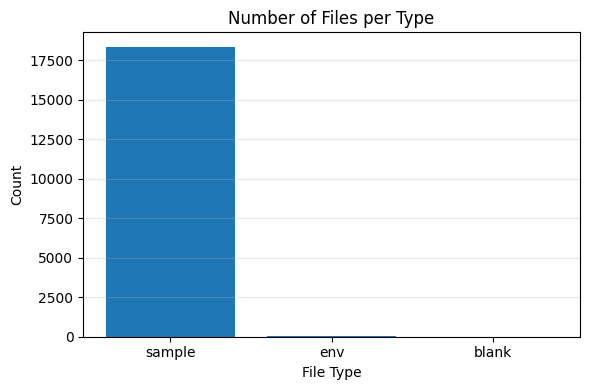

FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64


In [3]:


from compound_analysis_module import plot_filetype_counts

# Example usage
plot_filetype_counts(combined_df)


# Contamination filtering

Sample compounds before filtering: 18334
Sample compounds after filtering: 16602
Removed 1732 sample peaks (ΔRT ≤ 0.4)


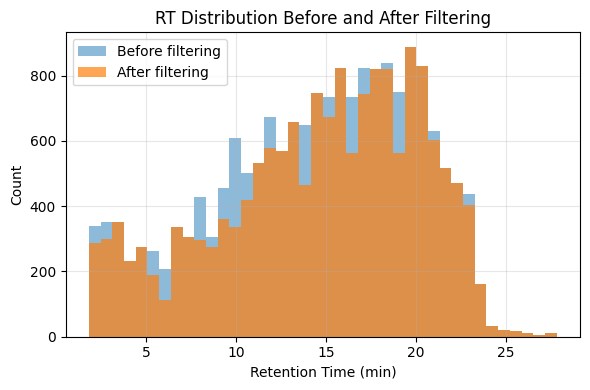

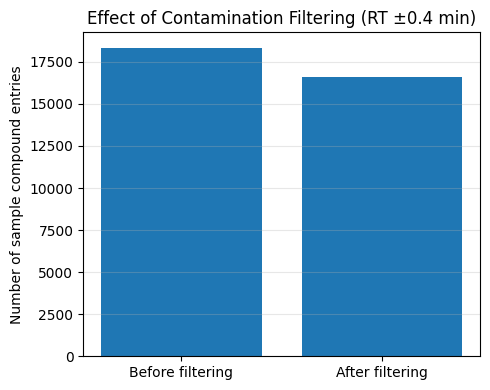

Before: 18334, After: 16602


In [4]:


from compound_analysis_module import (
    filter_real_compounds,
    plot_rt_distribution,
    plot_filtering_effect
)

# Filtering
real_compounds = filter_real_compounds(combined_df, rt_tolerance=0.4)

# Plots
plot_rt_distribution(combined_df, real_compounds)
plot_filtering_effect(combined_df, real_compounds, rt_tolerance=0.4)


Contamination filtering (RT ±0.4 min) reduces the number of sample compound entries noticeably, meaning a chunk of detections likely overlap with signals seen in the blank/environment controls. The filtering removes hits across the chromatogram rather than wiping out one specific RT region 

# Matching NIST-Identified Compounds with GC–MS Peak Intensities

# Loading the pereprocessed sample (biorep1)

In [5]:

csv_path = config["biorep1"]["data_paths"]["sample"]


# Load the data
samples_filtered = pd.read_csv(csv_path)

print(samples_filtered.head())


          Filename                            Sample  Peak     Variety  \
0  S96_44_B1_D1_T1     NLD;MET;96;64;2024;44;FELSINA     1     FELSINA   
1  S96_14_B1_D1_T1      NLD;MET;96;64;2024;14;AVARNA     1      AVARNA   
2  S96_83_B1_D1_T1  NLD;MET;96;64;2024;83;SARPO MIRA     1  SARPO MIRA   
3   S96_9_B1_D1_T1         NLD;MET;96;64;2024;9;ANTI     1        ANTI   
4  S96_28_B1_D1_T1      NLD;MET;96;64;2024;28;CHOPIN     1      CHOPIN   

   tR_best  m/z  Intensity_corrected  Ratio_normalized  Log10_normalized  
0    1.906   40          9561.412173          0.205644          0.081219  
1    1.906   40         18152.056716          0.390408          0.143142  
2    1.906   40         17123.838459          0.368294          0.136179  
3    1.906   40         14479.913782          0.311429          0.117745  
4    1.906   40         17643.764736          0.379476          0.139714  


# Checking the presence of known potato aroma compounds

This function maps NIST compound identification results (from combined_df) to a curated potato aroma list, builds a reference table of median RT/MZ per compound, and then performs strict matching to the quantified peak table in samples_filtered_path using RT ± rt_tol and m/z ± mz_tol for each Variety. It outputs a matched-per-variety table and a wide Variety × Compound intensity matrix

In [6]:
from compound_analysis_module import match_potato_aromas_strict
rename_map = {
    "Component": "Component RT",
    "Compound": "Compound Name",
    "Name": "Compound Name"
}
real_compounds = real_compounds.rename(
    columns={k: v for k, v in rename_map.items() if k in combined_df.columns}
)

real_compounds["FileType"] = "sample"

print("Combined rows:", len(combined_df))

biorep1_cfg = config["biorep1"]

res = match_potato_aromas_strict(
    combined_df=real_compounds,
    samples_filtered_path=biorep1_cfg["data_paths"]["sample"],
    out_dir="C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1",
    paths=paths,
    rt_tol=0.4,
    mz_tol=0.5
)



aroma_matrix_output = "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/aroma_matrix.csv"
os.makedirs(os.path.dirname(aroma_matrix_output ), exist_ok=True)
aroma_matrix = res["aroma_matrix"].copy()

print("Aroma matrix shape:", aroma_matrix.shape)
display(aroma_matrix.head())
aroma_matrix.to_csv(aroma_matrix_output )
print("Aroma matrix saved to:", aroma_matrix_output)


Combined rows: 18368
Aroma matrix shape: (94, 67)


Compound Name,Variety,(E)-2-Decenal,"(E, E)-2,4-Decadienal",1-Heptanol,1-Nonanol,1-Octen-3-ol,1-Penten-3-one,1-Phenylethanol,"2(3H)-Furanone, dihydro-5-pentyl-","2,3-Butanedione",...,Propanal,Propanoic acid,Styrene,Tetradecanal,Tetradecane,Tridecanal,Tridecane,Undecanal,alpha-Terpineol,n-Hexadecanoic acid
0,ADORA,4.447135e+05,7.304298e+04,2.784784e+05,2.136020e+05,228254.796383,6.794271e+05,48950.208686,9.239058e+05,3.088605e+06,...,17946.994870,4.947260e+05,1.773433e+06,6.133771e+05,2.250596e+05,1.712061e+06,3.824605e+04,2.452129e+06,6.430264e+05,4.575394e+06
1,AGRIA,1.437602e+05,3.018480e+04,6.179630e+04,2.757652e+04,57341.845143,2.315418e+05,26582.261754,2.052005e+05,1.339698e+06,...,15921.363108,1.953400e+05,1.004196e+06,1.946119e+05,1.026824e+05,5.383678e+05,4.355473e+04,6.239572e+05,2.279743e+05,1.097296e+06
2,ALOUETTE,3.063278e+05,8.193510e+04,1.529923e+05,5.330302e+04,121922.423267,4.037165e+05,37994.023056,1.330490e+06,1.791366e+06,...,21774.988619,4.933581e+05,1.662786e+06,4.282353e+05,2.950566e+05,1.562150e+06,9.894617e+04,1.476290e+06,5.935385e+05,9.395803e+05
3,ALTHEA,1.088533e+06,1.847740e+06,1.351440e+06,9.554670e+05,300194.592118,3.337000e+06,329589.938759,6.415808e+06,3.591327e+06,...,806620.793402,6.207546e+06,2.241380e+06,7.481153e+06,3.937370e+06,8.551076e+06,3.460950e+05,5.976313e+06,3.204490e+06,5.117058e+06
4,ALTURAS,3.157242e+05,1.221946e+05,3.676368e+06,1.825408e+06,249787.648279,5.243040e+05,102397.833169,7.381107e+05,3.372385e+06,...,76493.627136,7.577369e+05,3.888910e+06,8.954584e+05,3.826464e+05,1.196550e+06,3.466065e+06,2.288069e+06,2.390378e+05,4.669726e+06


Aroma matrix saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/aroma_matrix.csv


# Classification of Aroma Compounds by Chemical Family

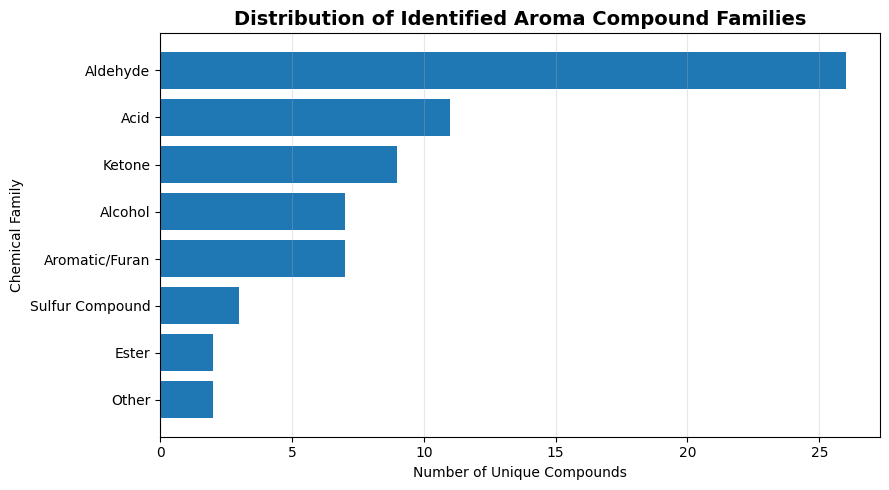

Chemical_Family
Aldehyde           26
Acid               11
Ketone              9
Alcohol             7
Aromatic/Furan      7
Sulfur Compound     3
Ester               2
Other               2
dtype: int64

In [7]:
from compound_analysis_module import (
    assign_aroma_descriptions_and_families,
    plot_aroma_family_distribution_unique
)

#  wide -> long
id_col = aroma_matrix.index.name or "Variety"

aroma_long = (
    aroma_matrix
    .reset_index()
    .melt(
        id_vars=[id_col],
        var_name="Compound Name",
        value_name="Intensity"
    )
    .rename(columns={id_col: "Variety"})
)

#  numeric cleanup
aroma_long["Intensity"] = (
    aroma_long["Intensity"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

aroma_long["Intensity"] = pd.to_numeric(aroma_long["Intensity"], errors="coerce")

#  filter
aroma_long = aroma_long.dropna(subset=["Intensity"])
aroma_long = aroma_long.loc[aroma_long["Intensity"] > 0].copy()

# annotate (IMPORTANT: unpack!)
aroma_long, aroma_desc_map, chemical_family_map = (
    assign_aroma_descriptions_and_families(aroma_long)
)

# plot
plot_aroma_family_distribution_unique(aroma_long)


Aldehydes dominate the identified aroma set, indicating that carbonyl-driven “green/fatty” notes are the most represented chemical class in this dataset. Acids, ketones, and alcohols form a secondary group, while sulfur compounds and esters are relatively rare

#  PCA + K-Means Clustering of Potato Aroma Profiles (k = 2; 64.8% Variance in PC1–PC2)

Explained variance (2 PCs): 64.76%
Optimal k (silhouette): 2


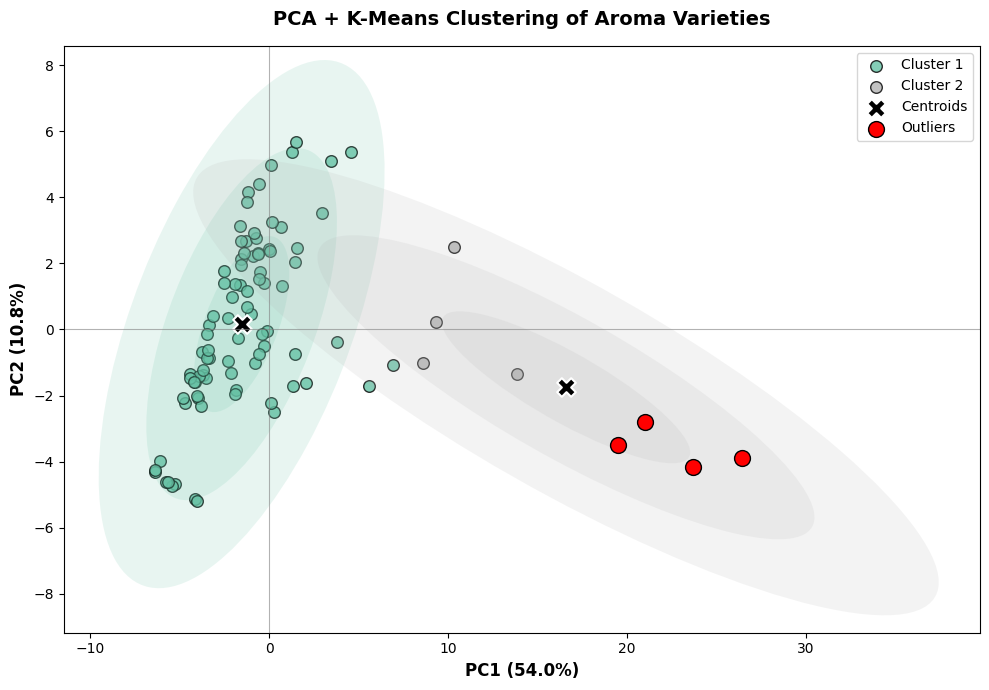

In [8]:

from compound_analysis_module import pca_kmeans_aroma

results, X_pca, clusters = pca_kmeans_aroma(aroma_matrix)


PCA on the aroma intensity matrix shows that the first two components capture ~64.8% of the total variation (PC1 54.0%, PC2 10.8%), meaning most between-variety differences are explained by a single dominant aroma gradient. Silhouette-based K-means selects k = 2, separating varieties into two main aroma-profile groups, with a few clear outliers lying far from the cluster centroids—these likely represent varieties with unusually distinct aroma compositions or extreme intensities.

# Hierarchical clustering analysis (HCA)

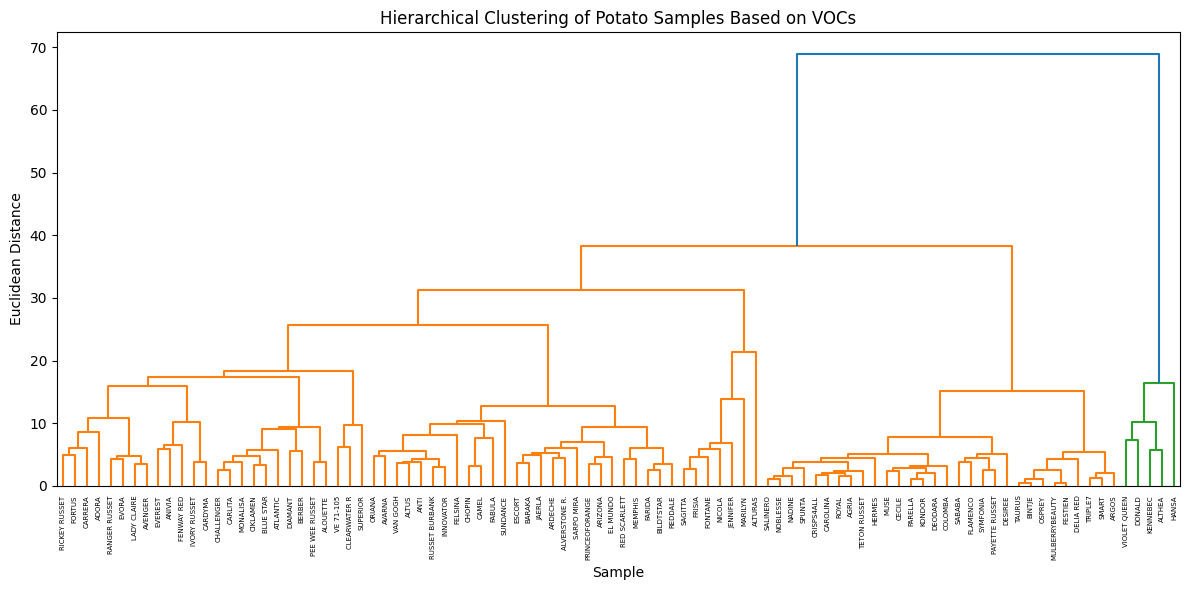

In [9]:


# Step 1: Drop non-numeric columns (e.g., 'Sample_ID', 'Genotype') if present
voc_df = aroma_matrix.select_dtypes(include='number')

# Step 2: Scale the numeric data
scaler = StandardScaler()
voc_scaled = scaler.fit_transform(voc_df)

# Step 3: Perform hierarchical clustering
linked = linkage(voc_scaled, method='ward')



labels = aroma_matrix['Variety'].values


# Step 5: Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           labels=labels,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering of Potato Samples Based on VOCs')
plt.xlabel('Sample')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()


# GMM Clustering of Aroma Profiles with PCA-Based Model Selection (AIC/BIC)

PCA comps for ≥90% variance: 9 (90.2%)


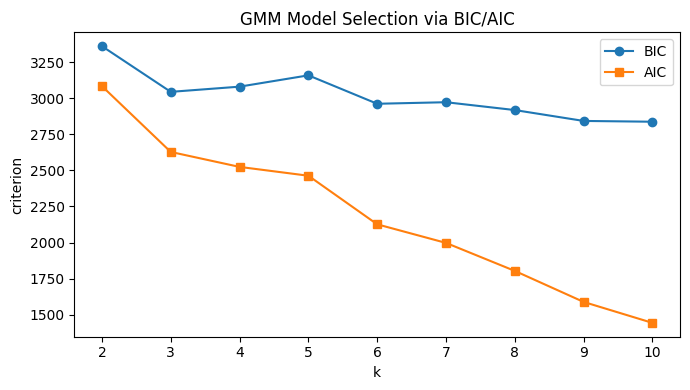

Best k by BIC: 10
Silhouette=0.267 | DBI=1.036 | CHI=41.9
Outliers detected: 4 / 94
Outlier varieties (sorted by Mahalanobis distance):
 - ALTHEA | Cluster=2 | Mahalanobis=4.637
 - KENNEBEC | Cluster=2 | Mahalanobis=4.240
 - VIOLET QUEEN | Cluster=2 | Mahalanobis=3.656
 - DONALD | Cluster=2 | Mahalanobis=3.497


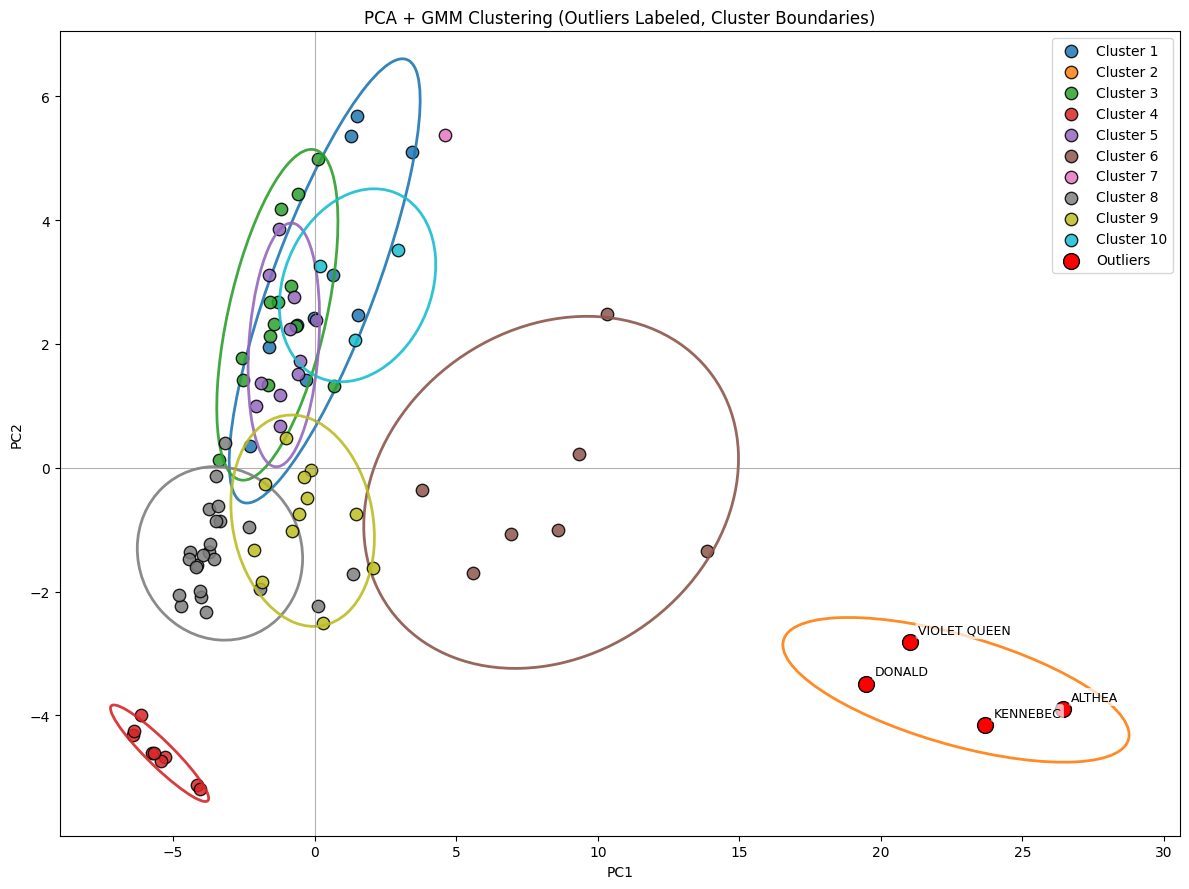

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


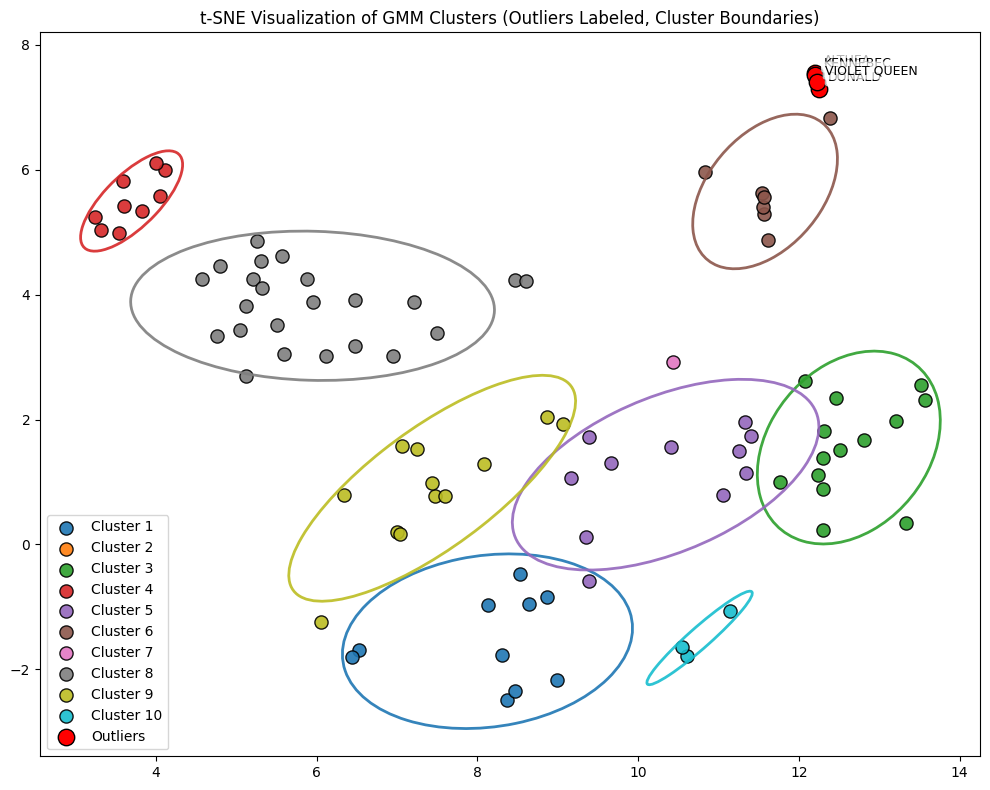

In [10]:

from compound_analysis_module import analyze_aroma_clusters_gmm
#  Run function 
results, cluster_means = analyze_aroma_clusters_gmm(aroma_matrix)


The aroma profiles are high-dimensional: it takes 9 PCA components to reach ~90% variance. AIC keeps favoring more clusters, while BIC is relatively flat with a mild best region around ~9–10, and the PCA map shows a few clear outliers with very distinct aroma profiles.

In [11]:
print(voc_df.columns)


Index(['(E)-2-Decenal', '(E, E)-2,4-Decadienal', '1-Heptanol', '1-Nonanol',
       '1-Octen-3-ol', '1-Penten-3-one', '1-Phenylethanol',
       '2(3H)-Furanone, dihydro-5-pentyl-', '2,3-Butanedione',
       '2,4-Heptadienal', '2-Acetyl-5-methylfuran', '2-Decanone',
       '2-Ethylfuran', '2-Heptanone', '2-Methylbutanal', '2-Methylpropanal',
       '2-Nonanone', '2-Nonenal, (E)-', '2-Propanone, 1-methoxy-',
       '2-Tridecenal', '2-Undecenal', '3-Carene', '3-Furaldehyde',
       '3-Heptanone', '3-Methylbutanal', '6-Methyl-5-hepten-2-one',
       'Acetic acid, ethenyl ester', 'Acetic acid, methyl ester',
       'Benzoic acid', 'Benzoic acid, methyl ester', 'Benzyl alcohol',
       'Butanal, 3-methyl-', 'Butanoic acid, butyl ester', 'Decanal',
       'Dimethyl disulfide', 'Dimethyl phthalate', 'Dimethyl trisulfide',
       'Dodecanal', 'Dodecanoic acid', 'Ethanol, 2-phenoxy-', 'Ethyl acetate',
       'Ethyl butanoate', 'Furan, 2-pentyl-', 'Furfural', 'Hexanal',
       'Hexanoic acid', 'He

# Comparative Analysis of Aroma Caompound Classes Between Outlier and other Potato Varieties

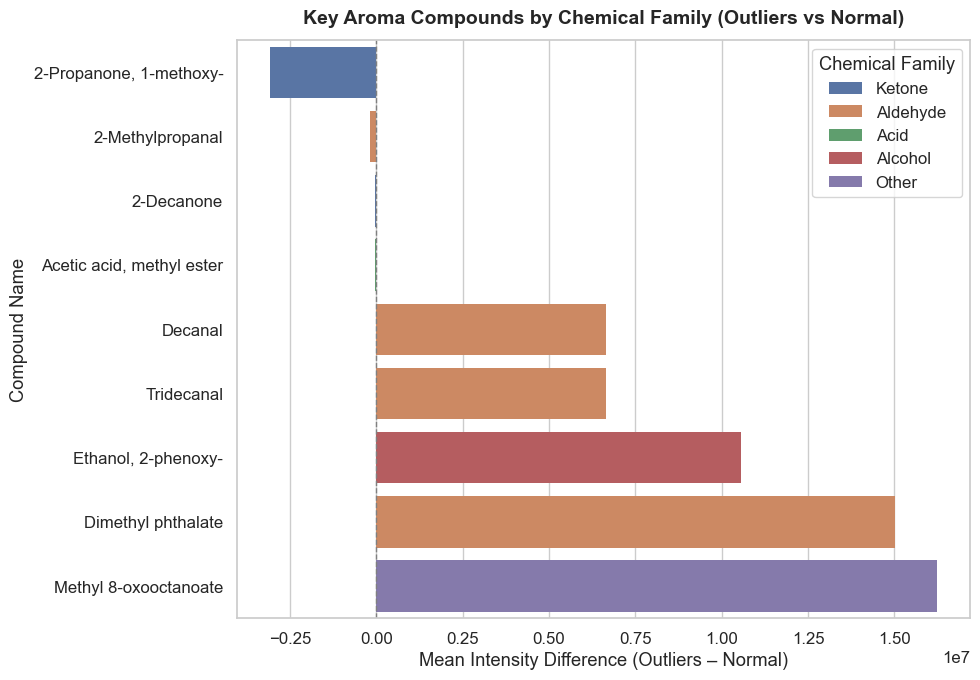

Saved plot: aroma_cluster_results\outlier_vs_normal_aromas.png


Group,Compound Name,Normal,Outlier,Difference,Chemical Family
18,"2-Propanone, 1-methoxy-",1.224168e+07,9.155594e+06,-3.086086e+06,Ketone
15,2-Methylpropanal,1.011486e+06,8.291000e+05,-1.823856e+05,Aldehyde
11,2-Decanone,3.576727e+05,3.234460e+05,-3.422674e+04,Ketone
27,"Acetic acid, methyl ester",4.246391e+05,3.920961e+05,-3.254303e+04,Acid
33,Decanal,9.256924e+05,7.577859e+06,6.652166e+06,Aldehyde
61,Tridecanal,9.256924e+05,7.577859e+06,6.652166e+06,Aldehyde
39,"Ethanol, 2-phenoxy-",9.311327e+05,1.148018e+07,1.054905e+07,Alcohol
35,Dimethyl phthalate,1.950850e+06,1.696749e+07,1.501664e+07,Aldehyde
48,Methyl 8-oxooctanoate,8.743373e+05,1.711377e+07,1.623943e+07,Other


In [12]:

from compound_analysis_module import plot_outlier_vs_normal_aromas


outliers =['ALTHEA', 'KENNEBEC', 'VIOLET QUEEN', 'DONALD']
top_diff = plot_outlier_vs_normal_aromas(aroma_matrix, outliers, chemical_family_map, output_dir="aroma_cluster_results")

display(top_diff)


Outlier varieties (ALTHEA, KENNEBEC, VIOLET QUEEN, DONALD) show strong positive shifts for a small set of compounds—most notably Methyl 8-oxooctanoate and Dimethyl phthalate, with additional increases in several aldehydes (e.g., Decanal, Tridecanal). In contrast, 2-Propanone, 1-methoxy- is reduced in outliers relative to the main group

#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


                                   mean         std
Compound Name                                      
2-Propanone, 1-methoxy-     12110357.50  6088218.31
Dimethyl disulfide           2735350.50  1945186.97
Dimethyl phthalate           2589855.84  3970915.49
3-Methylbutanal              2499609.53  1766555.41
n-Hexadecanoic acid          2180441.93  2149749.61
2,3-Butanedione              1700098.75   952515.66
Acetic acid, ethenyl ester   1700098.75   952515.66
Methyl 8-oxooctanoate        1565376.86  3761209.17
2-Heptanone                  1544355.92   990116.03
Ethanol, 2-phenoxy-          1380028.30  2467051.16


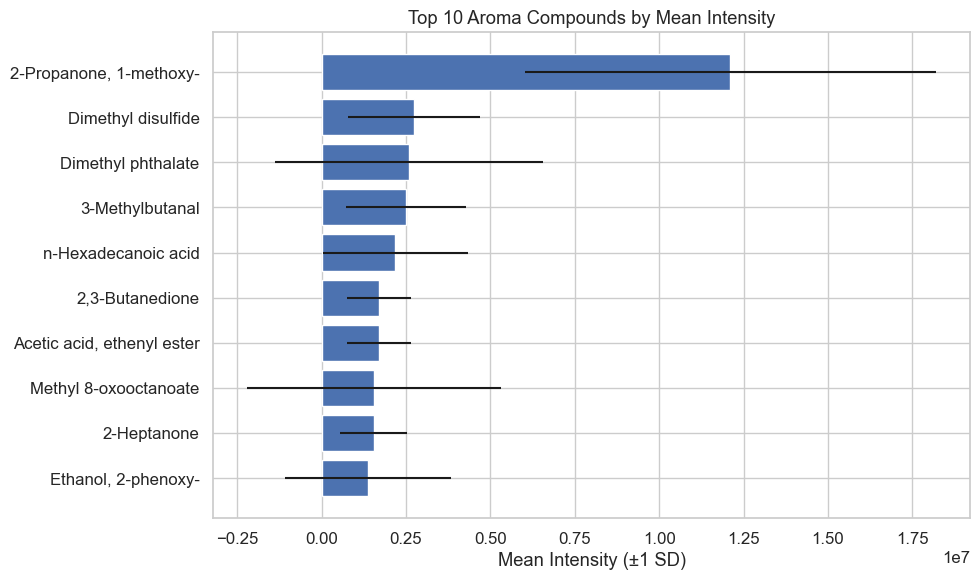

In [13]:

from compound_analysis_module import summarize_aroma_intensities

desc_stats, top_compounds = summarize_aroma_intensities(aroma_matrix, top_n=10)

Across varieties, 2-Propanone, 1-methoxy- has by far the highest mean intensity (~1.21×10⁷), standing out well above the other top compounds.

# Heatmap of Top Aroma Compounds in Potato Varieties

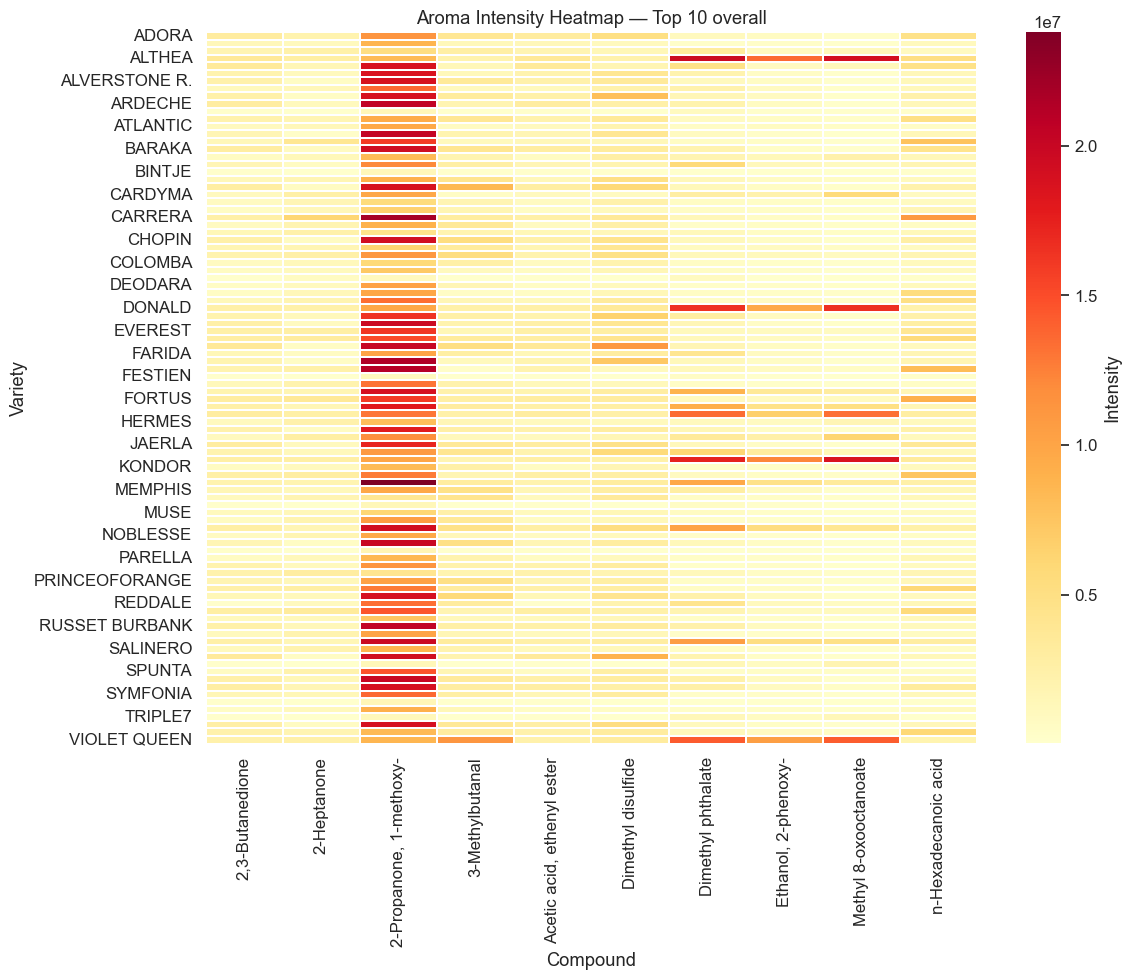

In [14]:
from compound_analysis_module import plot_top_aroma_heatmap


plot_top_aroma_heatmap(aroma_matrix, top_n=10, mode="overall")


This heatmap shows how the top 10 most intense compounds overall vary across varieties: most varieties have relatively low-to-moderate signals, but a few display strong “hot spots” for specific compounds. The strongest contrast is driven by 2-Propanone, 1-methoxy- (high in many varieties) and a small set of varieties with elevated Dimethyl phthalate / Ethanol, 2-phenoxy- / Methyl 8-oxooctanoate.

# Interactive Aroma Compound Dashboard for Potato Varieties

In [15]:

from compound_analysis_module import launch_aroma_dashboard

launch_aroma_dashboard(aroma_matrix)



Launching dashboard at: http://127.0.0.1:7031


# Correlation between aroma compounds

Using this dashboard, we can select a variety and view the aroma compounds associated with it.

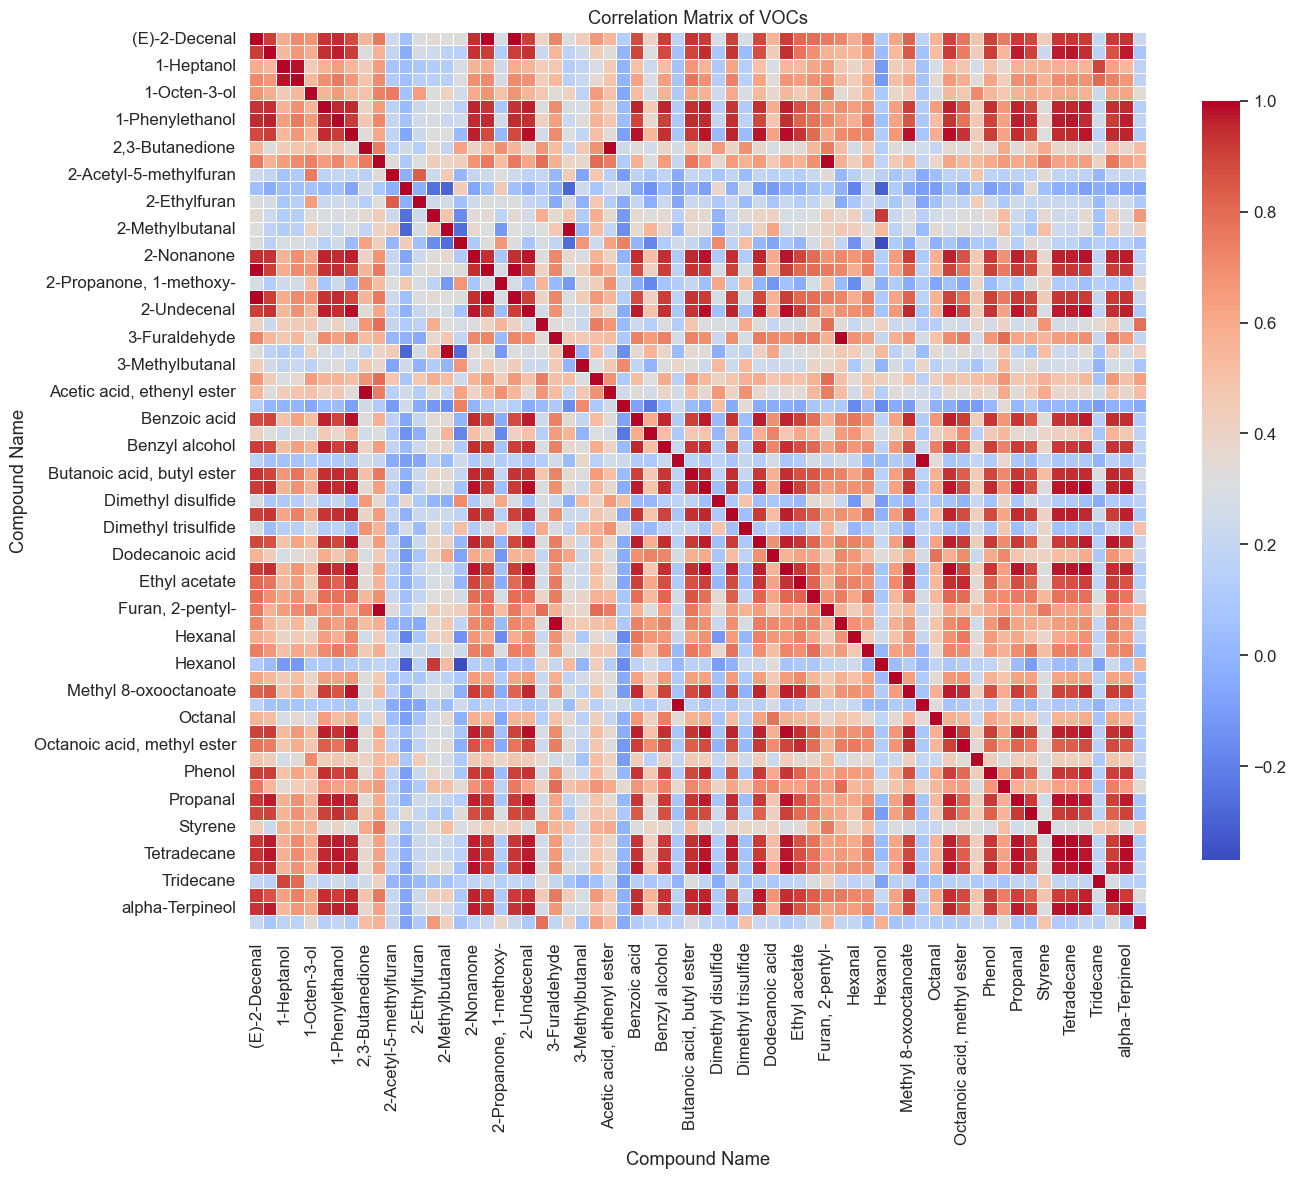

In [16]:


voc_df = aroma_matrix.drop(columns=['Variety'], errors='ignore')  

# Calculate Pearson correlation matrix
correlation_matrix = voc_df.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f",
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of VOCs')
plt.tight_layout()
plt.show()


red blocks suggest many VOCs co-vary, likely driven by shared factors

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings

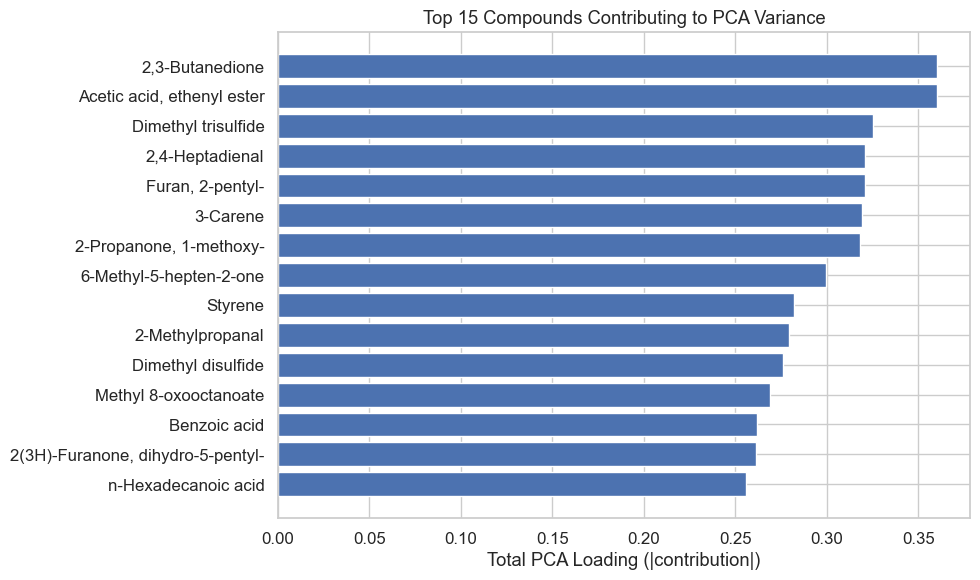

In [17]:

from compound_analysis_module import compute_feature_importance_from_pca
importance_df = compute_feature_importance_from_pca(aroma_matrix)


2,3-Butanedione and Acetic acid, ethenyl ester are the strongest drivers, followed by several sulfur/furan/aldehyde-related compounds (e.g., Dimethyl trisulfide, Furan, 2-pentyl-), these features are key markers behind the main differences captured by the PCA.

# Joining the sensory panel data 

In [18]:

# Read sensory Excel file using correct config path 
sensory_path = config["biorep1"]["data"]["sensory_data"]

# Load the sensory file
sensory = pd.read_excel(sensory_path)

# Preview
print("Columns:", list(sensory.columns))
display(sensory.head(config["biorep1"]["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Sensory Panel Data Processing

I selected some of the feature from sensory panel in order to link to aroma compounds

In [19]:

from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

Rows (unique varieties): 59
Traits averaged: 20
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0                        12.520             15.647 

# Merge aroma and sensory datasets

In [20]:

# COPY (SAFETY)
aroma_df   = aroma_matrix.copy()
sensory_df = sensory_summary.copy()



#  Aroma 
if "Variety" in aroma_df.columns:
    aroma_df["VARIETY"] = (
        aroma_df["Variety"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    raise KeyError("Aroma table must contain 'Variety' column")

#  Sensory 
if "VARIETY" in sensory_df.columns:
    sensory_df["VARIETY"] = (
        sensory_df["VARIETY"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
elif "Variety" in sensory_df.columns:
    sensory_df["VARIETY"] = (
        sensory_df["Variety"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    raise KeyError("Sensory table must contain VARIETY / Variety")


#  CHECK OVERLAP (DEBUG STEP)
common = sorted(
    set(aroma_df["VARIETY"]) &
    set(sensory_df["VARIETY"])
)

print("Aroma varieties:", aroma_df["VARIETY"].nunique())
print("Sensory varieties:", sensory_df["VARIETY"].nunique())
print("Common varieties:", len(common))
print("Example common:", common[:10])


# MERGE (INNER = ONLY COMMON)

merged_aroma_sensory = (
    aroma_df
    .merge(
        sensory_df,
        on="VARIETY",
        how="inner",
        validate="one_to_one"
    )
)

print("Merged rows:", merged_aroma_sensory.shape[0])

merged_aroma_sensory.head()


Aroma varieties: 94
Sensory varieties: 59
Common varieties: 20
Example common: ['ADORA', 'AGRIA', 'BERBER', 'BILDTSTAR', 'BINTJE', 'CARRERA', 'CECILE', 'CHALLENGER', 'DESIREE', 'FABULA']
Merged rows: 20


,Variety,(E)-2-Decenal,"(E, E)-2,4-Decadienal",1-Heptanol,1-Nonanol,1-Octen-3-ol,1-Penten-3-one,1-Phenylethanol,"2(3H)-Furanone, dihydro-5-pentyl-","2,3-Butanedione",...,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,ADORA,444713.487072,73042.975487,278478.391890,213601.957126,228254.796383,679427.054388,48950.208686,9.239058e+05,3.088605e+06,...,1.790,18.537,15.953,4.385,21.588,19.845,3.491,29.071,28.018,16.498
1,AGRIA,143760.167048,30184.804538,61796.296221,27576.519763,57341.845143,231541.761223,26582.261754,2.052005e+05,1.339698e+06,...,1.203,23.580,12.801,3.298,23.219,15.823,1.752,26.592,35.300,9.280
2,BERBER,264171.066303,234031.770342,115883.698661,65932.712220,97495.172973,570999.433413,43413.806791,1.079736e+06,7.565353e+05,...,3.355,16.732,10.866,7.146,24.719,12.410,4.535,31.505,34.713,7.520
3,BILDTSTAR,235465.349722,106300.593681,226904.393057,148428.133062,94331.666392,327782.103117,43928.898083,5.760281e+05,1.618706e+06,...,0.756,22.512,16.668,2.590,21.487,17.625,2.791,24.566,30.645,7.869
4,BINTJE,37264.617231,8090.086724,16416.985863,8994.336636,8158.109536,49498.746681,3823.695966,6.354591e+04,1.545169e+05,...,3.506,14.671,10.804,7.408,19.260,16.103,3.859,29.521,32.350,6.301


# Correlation between aroma compounds and sensory attributes

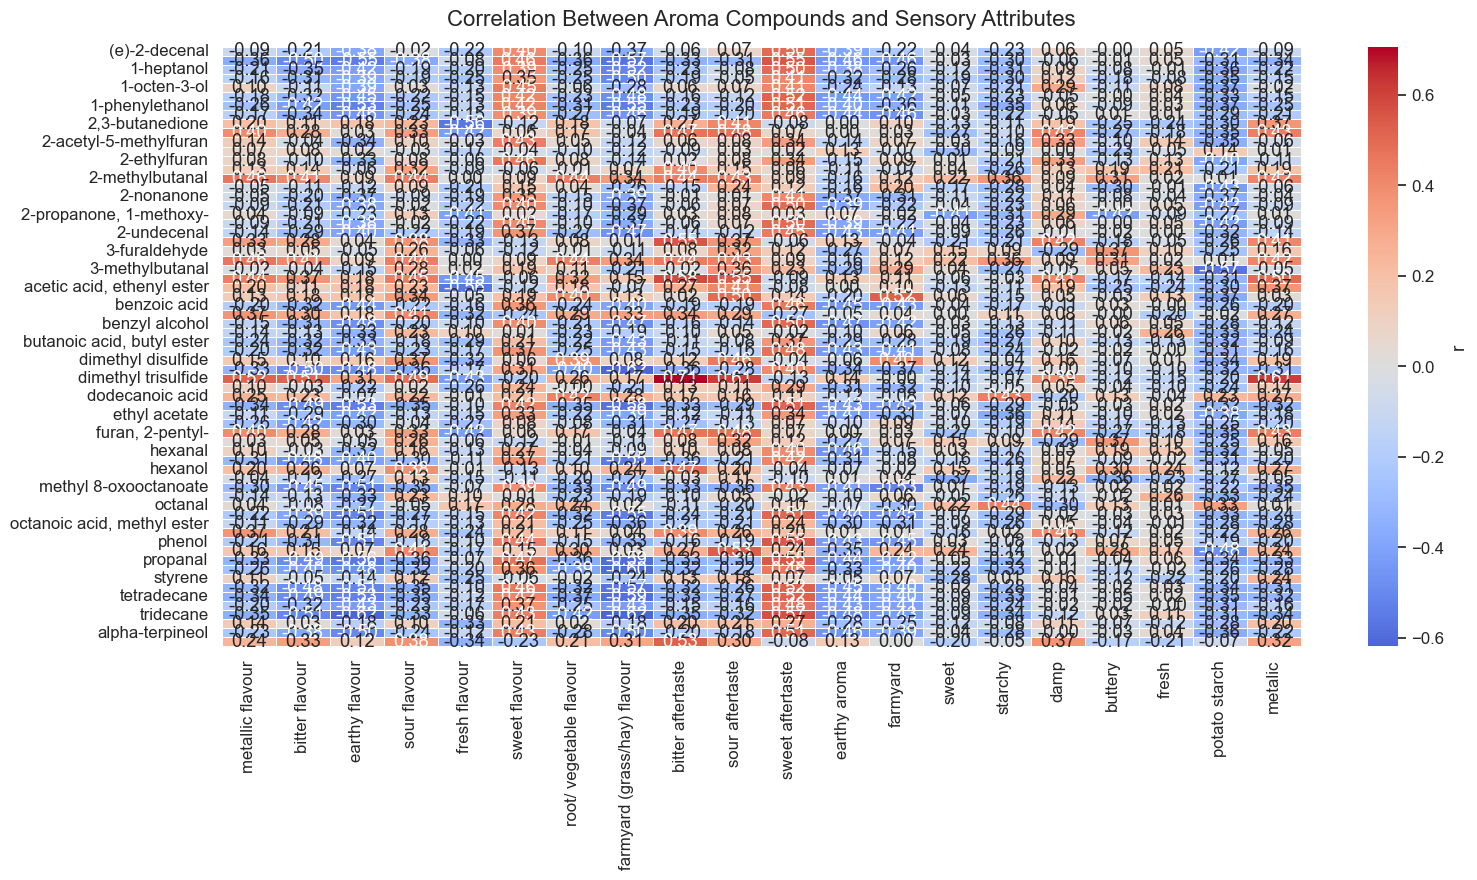

Saved: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/aroma_sensory_corr_output.csv


In [ ]:

from compound_analysis_module import plot_aroma_sensory_correlation

# Sensory columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

threshold = config["biorep1"]["settings"]["correlation_threshold"]
min_compounds = config["biorep1"]["settings"]["min_compounds"]

# FIXED: correct key
save_path = save_path = config["biorep1"]["data_paths"]["aroma_sensory_corr_output"]

corr_result = plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions={},   
    threshold=threshold,
    min_compounds=min_compounds,
    save_path=save_path
)



# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA

In [22]:
from compound_analysis_module import perform_knn_sensory_projection

# Paths from config
projection_path = config["biorep1"]["data_paths"]["aroma_sensory_corr_output"].replace(
    "aroma_sensory_corr_output.csv",
    "sensory_pca_projection_knn.csv"
)

loadings_path = projection_path.replace(
    "sensory_pca_projection_knn.csv",
    "sensory_pca_loadings.csv"
)

pc_df_path = projection_path.replace(
    "sensory_pca_projection_knn.csv",
    "sensory_pca_pc_df.csv"
)


# FIX aroma_long → aroma_wide 
aroma_long_fixed = aroma_long.copy()

if "VARIETY" not in aroma_long_fixed.columns and "Variety" in aroma_long_fixed.columns:
    aroma_long_fixed = aroma_long_fixed.rename(columns={"Variety": "VARIETY"})

aroma_long_fixed["VARIETY"] = (
    aroma_long_fixed["VARIETY"]
    .astype(str)
    .str.strip()
    .str.upper()
)

aroma_wide = (
    aroma_long_fixed
    .pivot_table(
        index="VARIETY",
        columns="Compound Name",
        values="Intensity",
        aggfunc="mean"
    )
    .reset_index()
)

# numeric safety
compound_cols = [c for c in aroma_wide.columns if c != "VARIETY"]
aroma_wide[compound_cols] = aroma_wide[compound_cols].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)


pc_df, pca, loadings_df = perform_knn_sensory_projection(
    aroma_matrix=aroma_wide,
    sensory_summary=sensory_summary,
    k=3,
    n_components=3,
    scaling_factor=15,
    save_projection_path=projection_path,
    save_loadings_path=loadings_path
)

Panel varieties: 20
Aroma non-panel varieties: 74
Explained variance ratio: [0.449 0.194 0.089]
Total projected varieties: 94


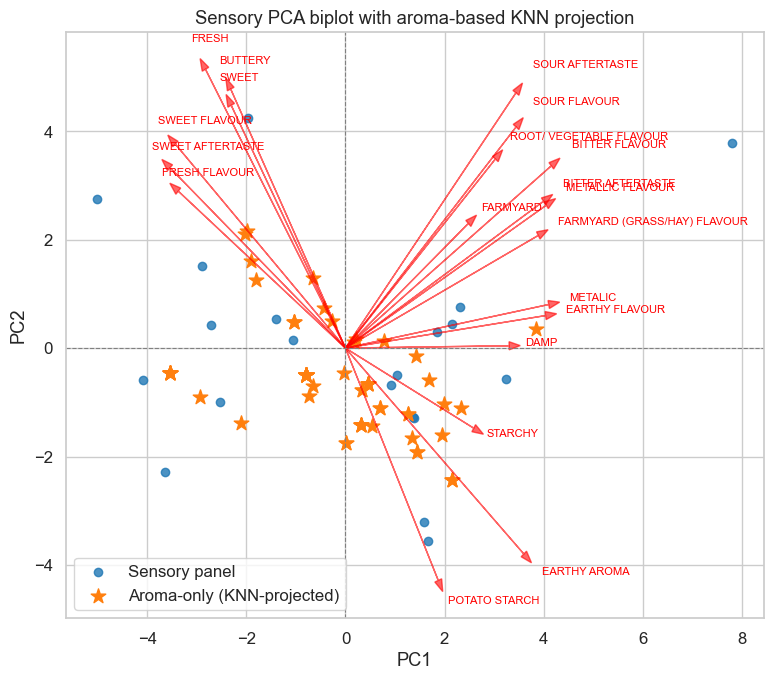

In [23]:
from compound_analysis_module import plot_sensory_pca_biplot

plot_sensory_pca_biplot(pc_df, loadings_df, scaling_factor=15)


This biplot shows the sensory flavour space (PC1–PC2) with red arrows indicating which sensory attributes drive the main directions of variation. The aroma-only varieties (orange stars) are projected into the same space via the aroma-based method, letting compare where they fall relative to the sensory panel varieties (blue) and which sensory notes they most closely align with